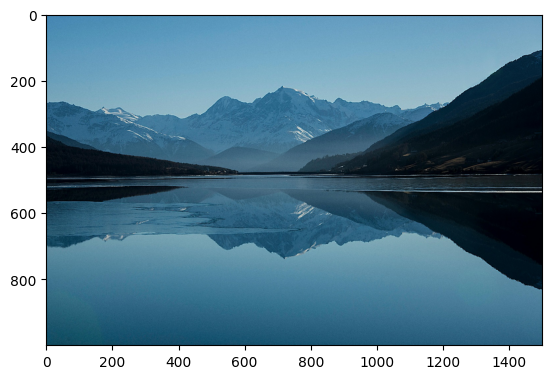

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('/kaggle/input/psd-dataset/lake.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

(1063, 1600, 3)


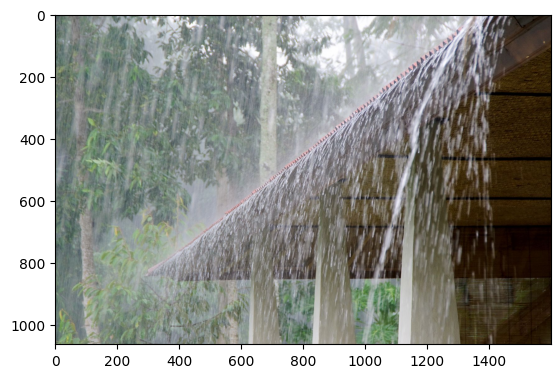

In [2]:
img_rain = cv.imread('/kaggle/input/psd-dataset/rain.jpg')
img_rain = cv.cvtColor(img_rain, cv.COLOR_BGR2RGB)

print(img_rain.shape)

plt.imshow(img_rain)
plt.show()

In [3]:
img_danau = img / 255.0
img_hujan = img_rain / 255.0

print(img_danau.shape)
print(img_hujan.shape)


(1000, 1500, 3)
(1063, 1600, 3)


# Penjumlahan dua buah image
(tidak bisa menjumlahkan 2 gambar dengan matriks yg berbeda, jadi harus disamakan terlebih dahulu)

(400, 600, 3)
(400, 600, 3)
(400, 600, 3)


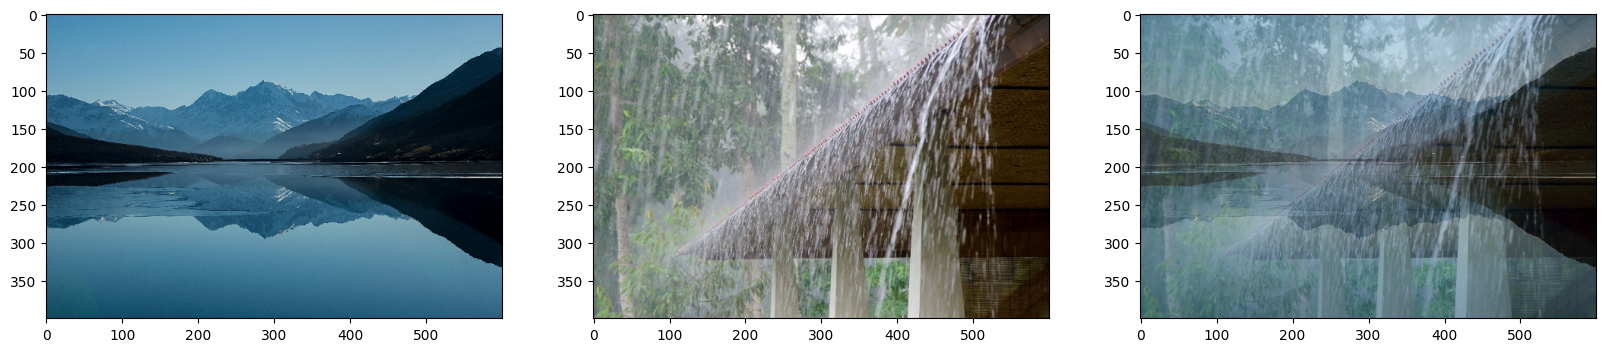

In [4]:
img_width = 600
img_height = 400

img_danau_resized = cv.resize(img_danau, (img_width, img_height))
img_rain_resized = cv.resize(img_hujan, (img_width, img_height))

print(img_danau_resized.shape)
print(img_rain_resized.shape)

img_sum = cv.addWeighted(img_danau_resized, 0.5, img_rain_resized, 0.5, 0.0)

print(img_sum.shape)

plt.figure(figsize=(20,20))
plt.subplot(1,3,1)
plt.imshow(img_danau_resized)


plt.subplot(1,3,2)
plt.imshow(img_rain_resized)


plt.subplot(1,3,3)
plt.imshow(img_sum)


plt.show()

(1000, 1500)


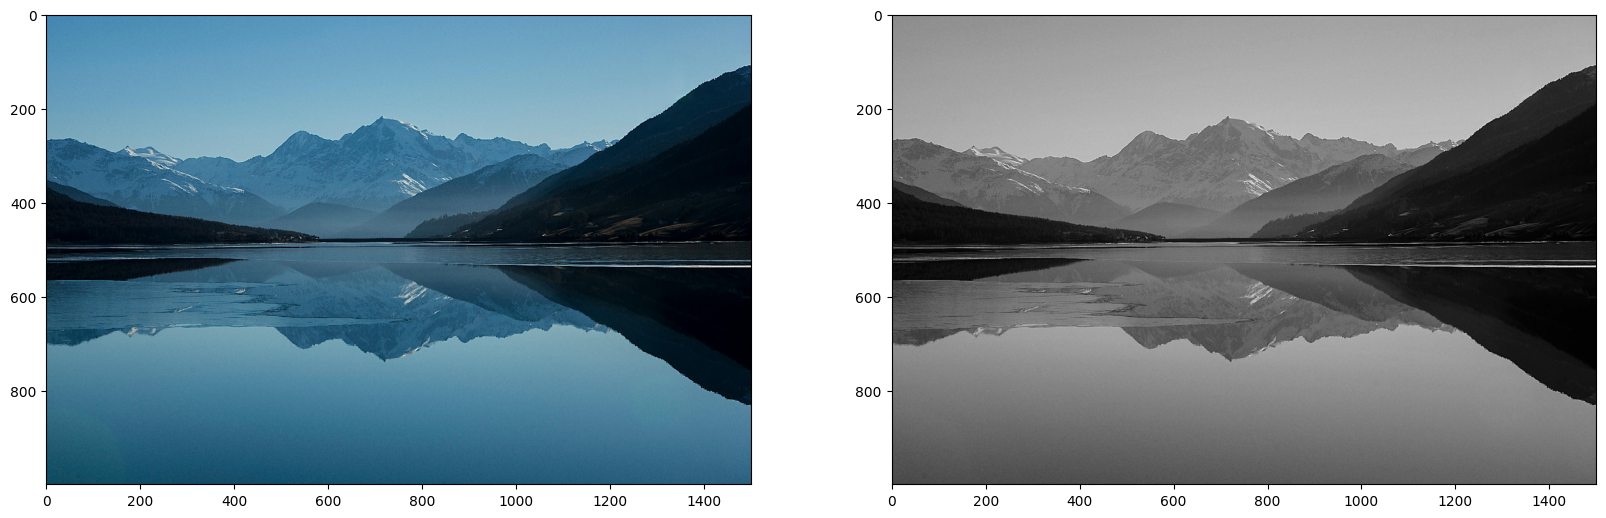

In [5]:
img_blend_grayscale = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print(img_blend_grayscale.shape)
plt.figure(figsize=(20,20))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(img_blend_grayscale, cmap= 'gray')

plt.show()

# Image Negatif

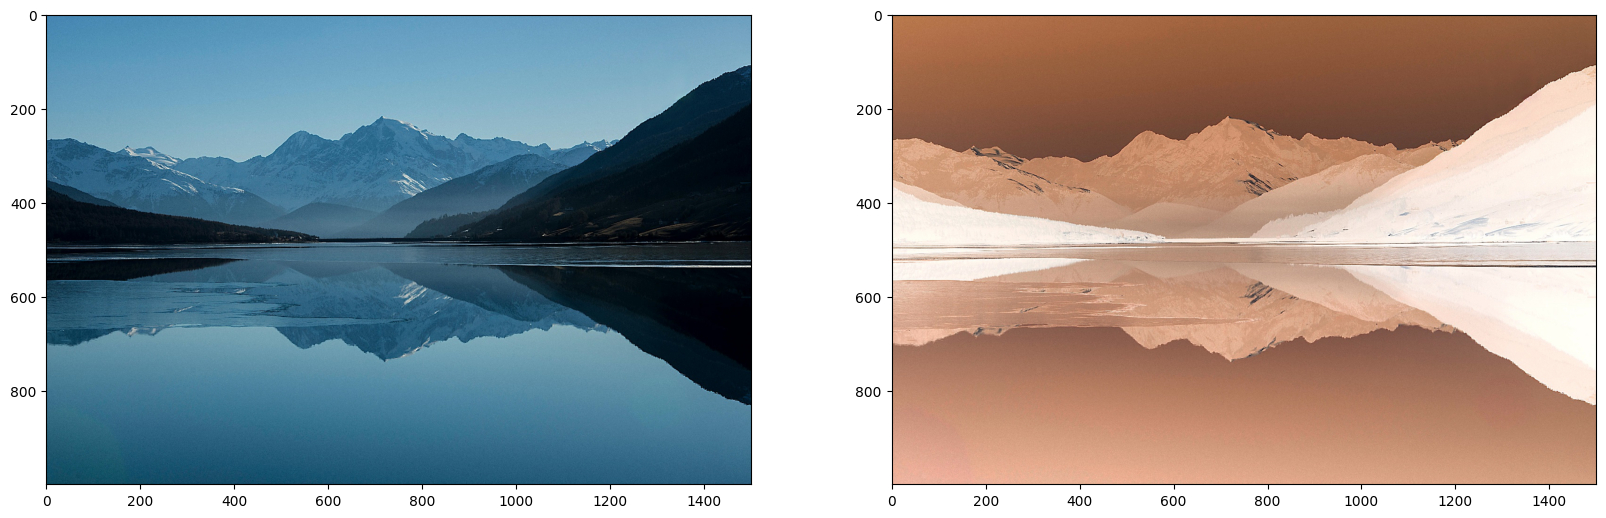

In [6]:
img_danau_negatif = 255 - img

plt.figure(figsize=(20,20))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(img_danau_negatif)
plt.show()

# Transformasi Logaritmik

/tmp/ipykernel_19/1890771681.py:5: RuntimeWarning: divide by zero encountered in log10
  img_danau_log = c * (np.log10(img + 1))
/tmp/ipykernel_19/1890771681.py:6: RuntimeWarning: invalid value encountered in cast
  img_danau_log = np.array(img_danau_log, dtype=np.uint8)


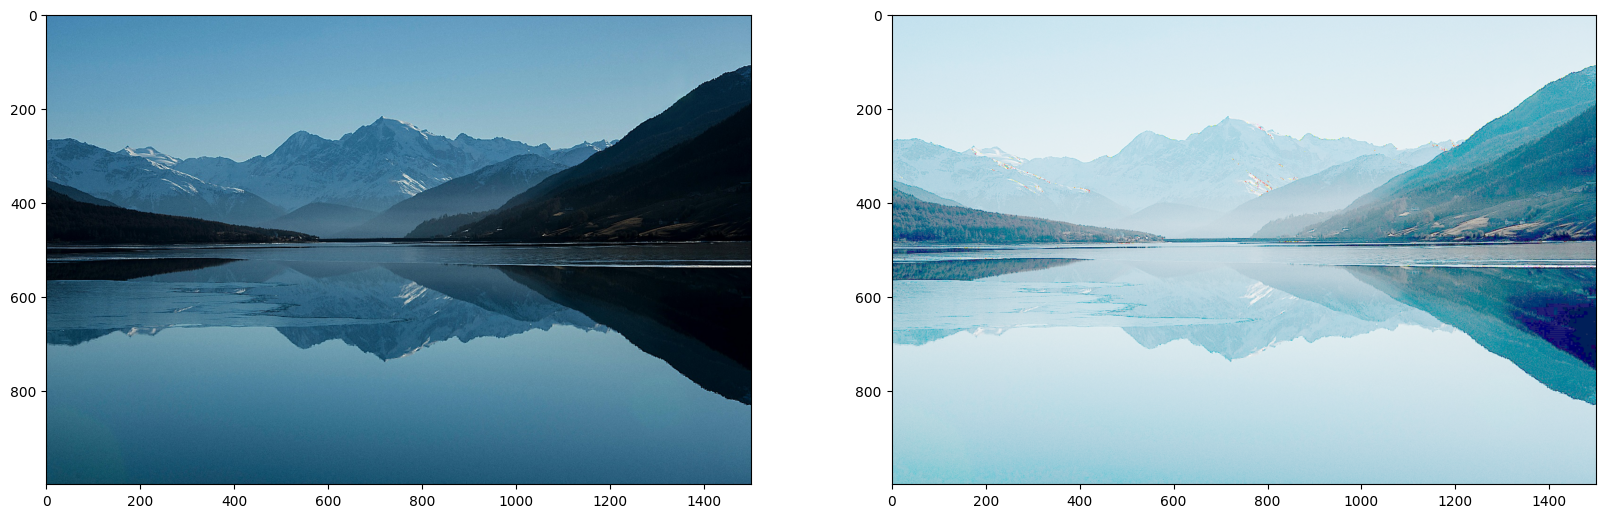

In [7]:
import numpy as np

c = 255 / np.log10(1 + np.max(img))

img_danau_log = c * (np.log10(img + 1))
img_danau_log = np.array(img_danau_log, dtype=np.uint8)

plt.figure(figsize=(20,20))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1,2, 2)
plt.imshow(img_danau_log)
plt.show()

# Transformasi Gamma

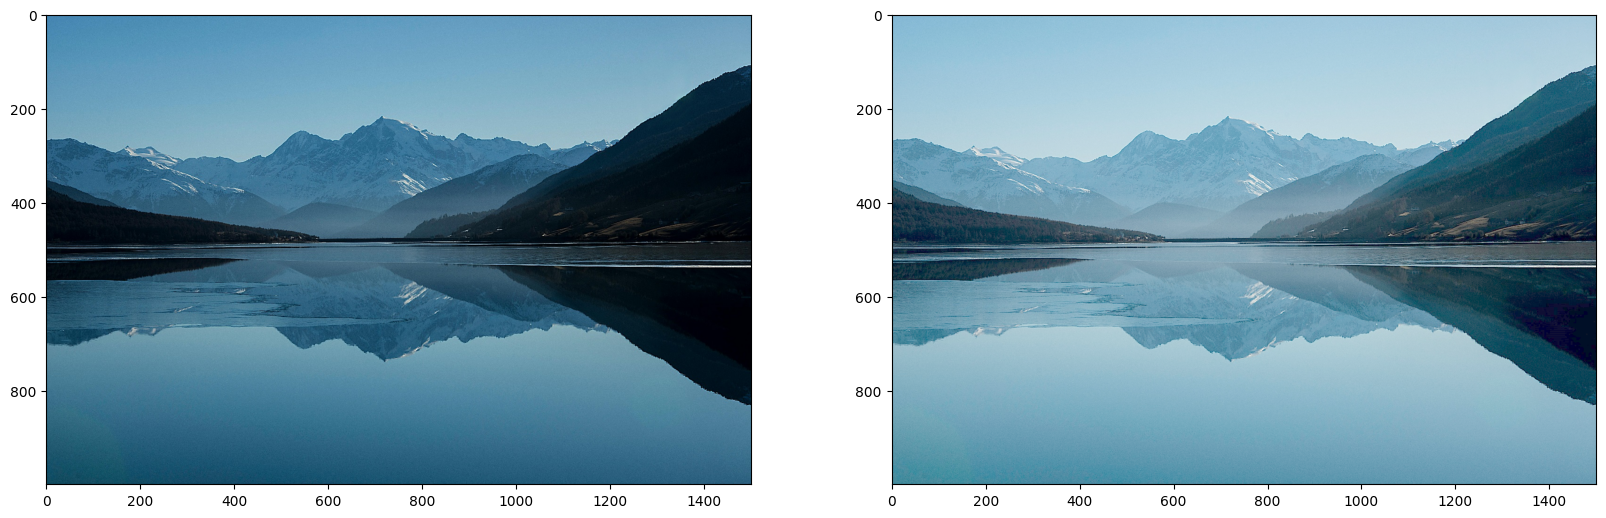

In [8]:
gamma = 0.5
img_danau_gamma = np.power(img / 255.0, gamma)

plt.figure(figsize=(20,20))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1,2, 2)
plt.imshow(img_danau_gamma)
plt.show()

# Praktikum 3 (Kernel FIltering)

1. Blurring

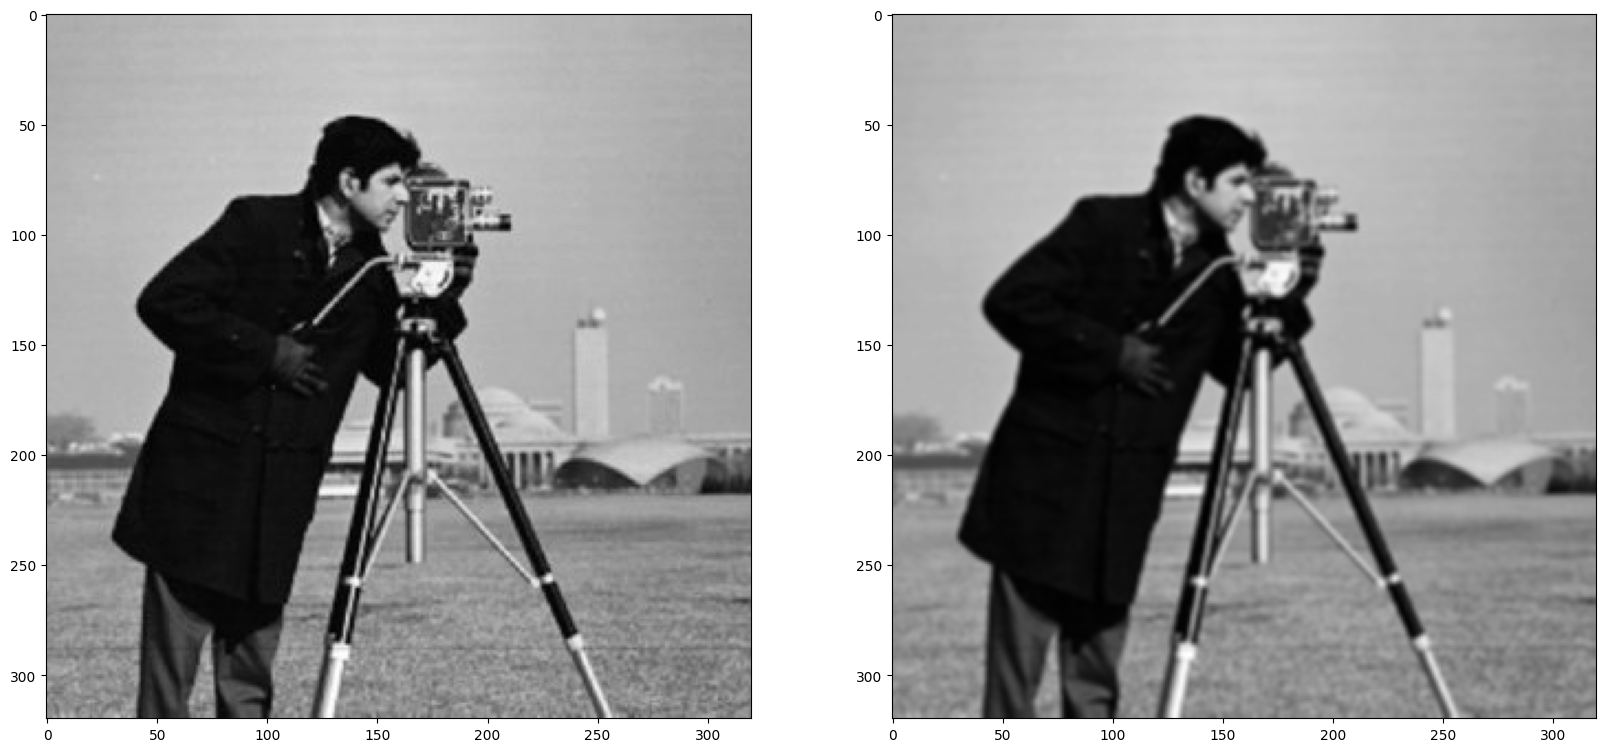

In [9]:
img_cam = cv.imread('/kaggle/input/psd-dataset/cameraman.jpg')
img_cam = cv.cvtColor(img_cam, cv.COLOR_BGR2GRAY) / 255.0
kernel = np.ones((3,3), np.float32) / 9
img_cam_blur = cv.filter2D(img_cam, -1, kernel)

plt.figure(figsize=(20,20))
plt.subplot(1, 2, 1)
plt.imshow(img_cam, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(img_cam_blur, cmap='gray')
plt.show()

# image sharpening

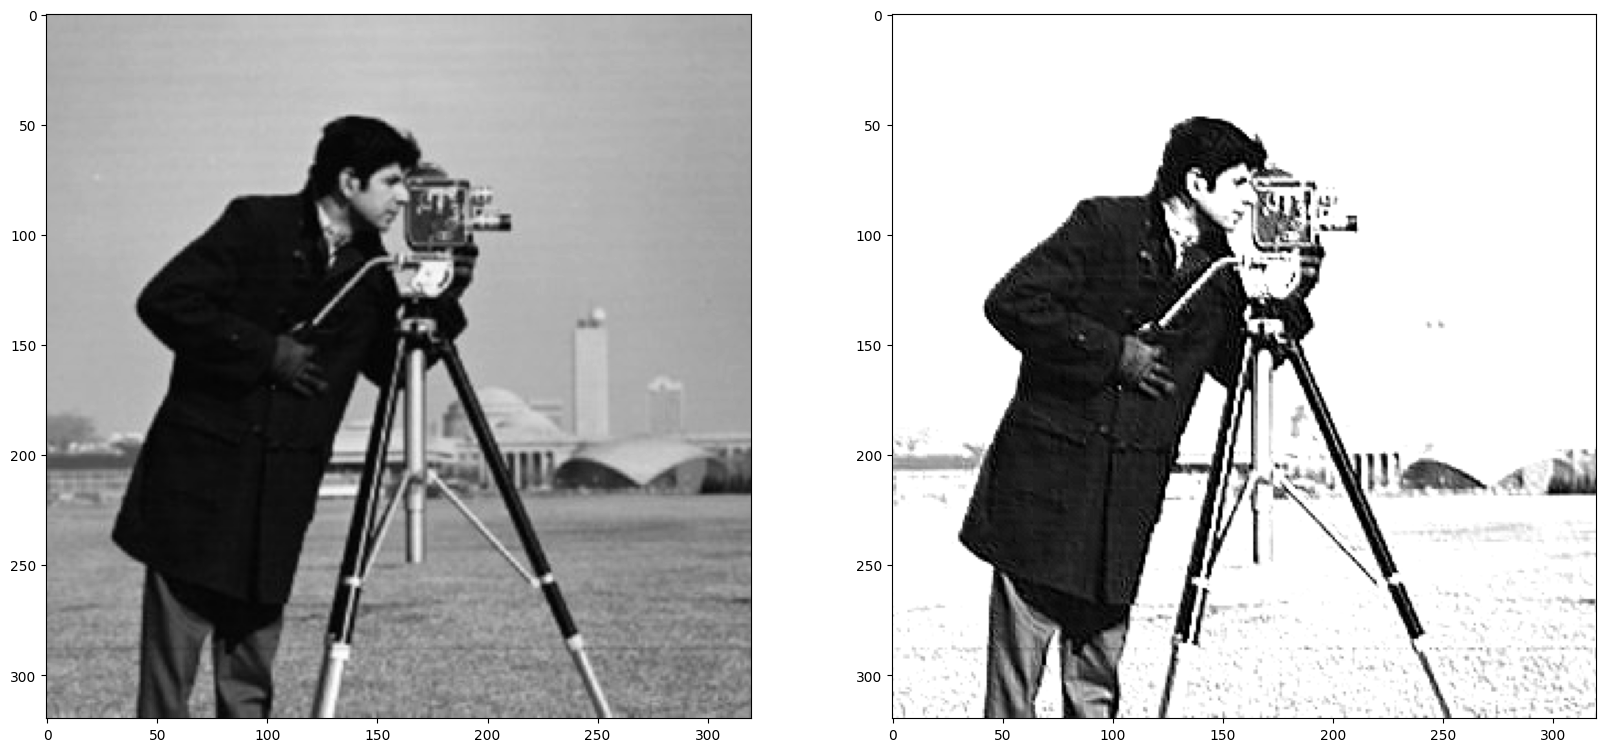

In [10]:
img_cam = cv.imread('/kaggle/input/psd-dataset/cameraman.jpg')
img_cam = cv.cvtColor(img_cam, cv.COLOR_BGR2GRAY) 
kernel = np.array([
    [1, 0, -1],
    [-1, 5, -1],
    [0, -1, 0]
])
img_cam_sharp = cv.filter2D(img_cam, -1, kernel)

plt.figure(figsize=(20,20))
plt.subplot(1, 2, 1)
plt.imshow(img_cam, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(img_cam_sharp, cmap='gray')
plt.show()

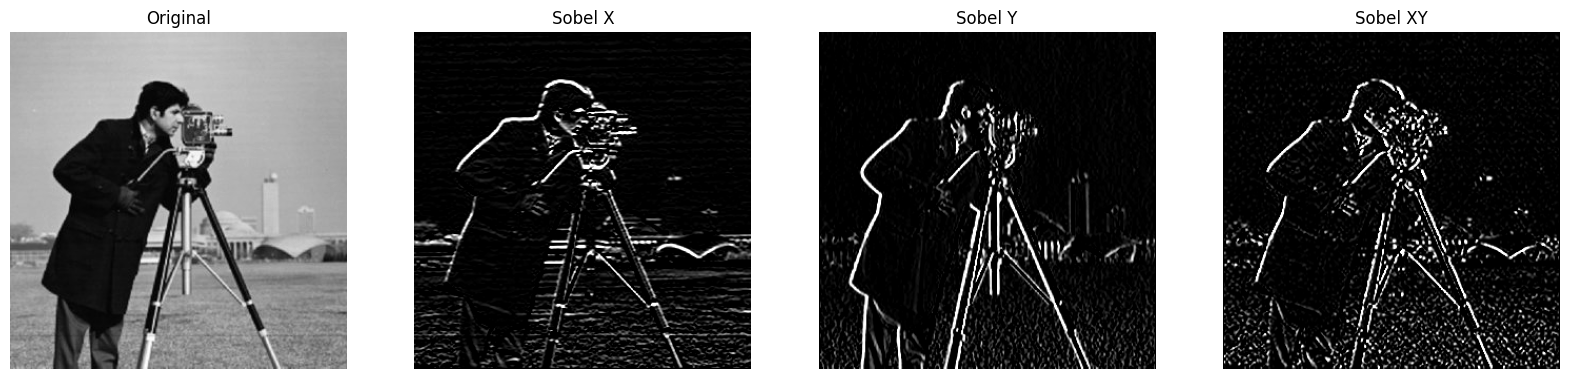

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar dan konversi ke grayscale
img_cam = cv.imread('/kaggle/input/psd-dataset/cameraman.jpg')
img_cam = cv.cvtColor(img_cam, cv.COLOR_BGR2GRAY)

# Kernel Sobel untuk arah Y
kernel_y = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])
img_cam_sobel_y = cv.filter2D(img_cam, -1, kernel_y)

# Kernel Sobel untuk arah X
kernel_x = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])
img_cam_sobel_x = cv.filter2D(img_cam, -1, kernel_x)

# Gabungan Sobel X dan Y
img_cam_sobel_xy = cv.filter2D(img_cam_sobel_x, -1, kernel_y)

# Plot 4 gambar
plt.figure(figsize=(20, 20))

plt.subplot(1, 4, 1)
plt.imshow(img_cam, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_cam_sobel_x, cmap='gray')
plt.title("Sobel X")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_cam_sobel_y, cmap='gray')
plt.title("Sobel Y")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_cam_sobel_xy, cmap='gray')
plt.title("Sobel XY")
plt.axis('off')

plt.show()


# Image Dalam Domain Frekuensi

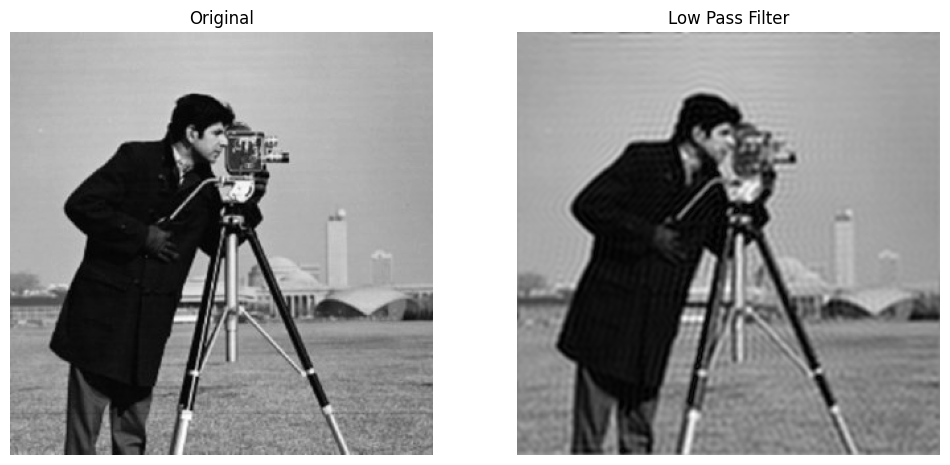

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar cameraman dalam grayscale
img_cameraman_gray = cv.imread('/kaggle/input/psd-dataset/cameraman.jpg', cv.IMREAD_GRAYSCALE)

def low_pass_filter(img_input, radius):
    fft = cv.dft(np.float32(img_input), flags=cv.DFT_COMPLEX_OUTPUT)
    dshift = np.fft.fftshift(fft)
    rows, cols = img_input.shape[:2]
    mid_row, mid_col = int(rows / 2), int(cols / 2)
    mask = np.zeros((rows, cols, 2), np.float32)
    mask[mid_row - radius:mid_row + radius, mid_col - radius:mid_col + radius] = 1
    fft_filtering = dshift * mask
    ishift = np.fft.ifftshift(fft_filtering)
    img_output = cv.idft(ishift)
    img_output = cv.magnitude(img_output[:,:,0], img_output[:,:,1])
    cv.normalize(img_output, img_output, 0, 1, cv.NORM_MINMAX)
    return img_output

# Normalisasi ke float
img_cameraman_float = np.float32(img_cameraman_gray) / 255
img_cameraman_lowpass = low_pass_filter(img_cameraman_float, 50)

# Tampilkan 2 gambar berdampingan
plt.figure(figsize=(12, 12))

plt.subplot(1, 2, 1)
plt.imshow(img_cameraman_gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_cameraman_lowpass, cmap='gray')
plt.title("Low Pass Filter")
plt.axis('off')

plt.show()
